# **Day 61: Training Deep Networks - Initialisation, Normalisation, Dropout and Schedules**
*Module 10 - Deep Learning Foundations*

Deep networks are powerful but hard to train: gradients vanish or explode, training is slow or unstable, and big models overfit. A handful of techniques, now standard in every architecture, solve most of these problems.

> Deep networks train well only with good habits: sensible weight initialisation, normalisation layers, dropout against overfitting, and a learning-rate schedule. These small choices often decide success or failure.
>
> *Example:* Dropout randomly switches off 30% of neurons during training, so the network cannot rely on one "lucky" feature.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, copy
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
torch.manual_seed(61)

X, y = load_digits(return_X_y=True)
X = (X / 16.0).astype(np.float32)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
X_tr, y_tr = X_tr[:600], y_tr[:600]                          # small training set: overfitting becomes visible
to_t = lambda a, b: TensorDataset(torch.tensor(a), torch.tensor(b))
dl_tr = DataLoader(to_t(X_tr, y_tr), batch_size=32, shuffle=True); dl_te = DataLoader(to_t(X_te, y_te), batch_size=512)

def train(model, epochs=60, opt=None, sched=None, clip=None, loss_fn=nn.CrossEntropyLoss()):
    opt = opt or torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)
    hist = []
    for ep in range(epochs):
        model.train(); tl = 0
        for xb, yb in dl_tr:
            opt.zero_grad(); loss = loss_fn(model(xb), yb); loss.backward()
            if clip: nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step(); tl += loss.item() * len(yb)
            if sched is not None and isinstance(sched, torch.optim.lr_scheduler.OneCycleLR): sched.step()
        if sched is not None and not isinstance(sched, torch.optim.lr_scheduler.OneCycleLR): sched.step()
        model.eval()
        with torch.no_grad():
            Xt, yt = dl_te.dataset.tensors; out = model(Xt)
            hist.append({"train_loss": tl / len(X_tr), "test_loss": loss_fn(out, yt).item(), "test_acc": (out.argmax(1) == yt).float().mean().item()})
    return pd.DataFrame(hist)

def deep_mlp(depth=8, width=128, act=nn.ReLU, bn=False, dropout=0.0, init=None):
    layers, n_in = [], 64
    for _ in range(depth):
        lin = nn.Linear(n_in, width)
        if init == "small": nn.init.normal_(lin.weight, 0, 0.01)
        elif init == "large": nn.init.normal_(lin.weight, 0, 1.0)
        elif init == "xavier": nn.init.xavier_normal_(lin.weight)
        elif init == "he": nn.init.kaiming_normal_(lin.weight, nonlinearity="relu")
        layers += [lin] + ([nn.BatchNorm1d(width)] if bn else []) + [act()] + ([nn.Dropout(dropout)] if dropout else [])
        n_in = width
    layers.append(nn.Linear(n_in, 10))
    return nn.Sequential(*layers)

## **1. Initialisation and Gradient Flow**
If weights are too small, signals shrink layer after layer (vanishing); too large, they explode. Good initialisations keep the **variance of activations constant** across layers:
- **Xavier/Glorot** (tanh, sigmoid): $\text{Var}(W) = \frac{2}{n_{in} + n_{out}}$
- **He/Kaiming** (ReLU): $\text{Var}(W) = \frac{2}{n_{in}}$ (ReLU zeros half the units)

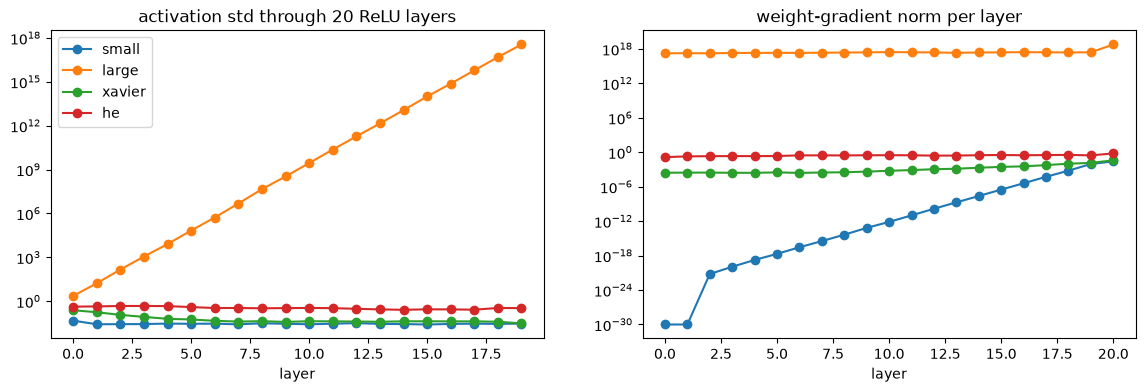

In [2]:
def activation_stats(model, x):
    stds = []; h = x
    for layer in model:
        h = layer(h)
        if isinstance(layer, (nn.ReLU, nn.Tanh)): stds.append(h.std().item())
    return stds
xb = torch.tensor(X_tr[:256])
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for init in ["small", "large", "xavier", "he"]:
    axes[0].semilogy(activation_stats(deep_mlp(20, init=init), xb), "o-", label=init)
    m = deep_mlp(20, init=init); loss = nn.CrossEntropyLoss()(m(xb), torch.tensor(y_tr[:256])); loss.backward()
    axes[1].semilogy([l.weight.grad.norm().item() + 1e-30 for l in m if isinstance(l, nn.Linear)], "o-", label=init)
axes[0].set(title="activation std through 20 ReLU layers", xlabel="layer"); axes[1].set(title="weight-gradient norm per layer", xlabel="layer")
axes[0].legend(); plt.show()

PyTorch's default `nn.Linear` init (Kaiming-uniform with a=sqrt(5)) is reasonable, but for deep ReLU stacks explicit He init is safer.

## **2. Batch Normalisation**
BatchNorm standardises each feature over the mini-batch, then applies a learned scale and shift: $\hat h = \gamma\frac{h - \mu_B}{\sqrt{\sigma_B^2+\epsilon}} + \beta$. It stabilises and **accelerates** training, allows higher learning rates, and slightly regularises. At test time it uses running averages (hence `model.eval()`!). **LayerNorm** normalises over features per sample (used in transformers and RNNs, independent of batch size).

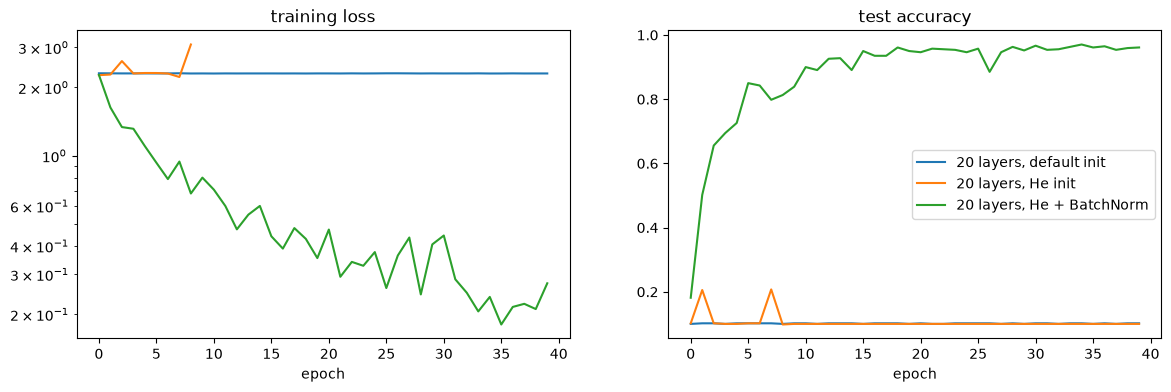

In [3]:
runs = {"20 layers, default init": deep_mlp(20), "20 layers, He init": deep_mlp(20, init="he"), "20 layers, He + BatchNorm": deep_mlp(20, init="he", bn=True)}
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, m in runs.items():
    torch.manual_seed(0); h = train(m, epochs=40)
    axes[0].plot(h.train_loss, label=name); axes[1].plot(h.test_acc, label=name)
axes[0].set(title="training loss", yscale="log", xlabel="epoch"); axes[1].set(title="test accuracy", xlabel="epoch"); axes[1].legend(); plt.show()

In [4]:
bn = nn.BatchNorm1d(3); data = torch.randn(64, 3) * torch.tensor([1.0, 10.0, 0.1]) + 5
bn.train(); out_train = bn(data)
print("train mode: output mean", out_train.mean(0).detach().round(decimals=3).tolist(), "std", out_train.std(0).detach().round(decimals=3).tolist())
bn.eval(); print("eval mode uses running stats: running_mean", bn.running_mean.round(decimals=3).tolist())

train mode: output mean [0.0, 0.0, -0.0] std [1.0080000162124634, 1.0080000162124634, 1.0069999694824219]
eval mode uses running stats: running_mean [0.5220000147819519, 0.41999998688697815, 0.49900001287460327]


## **3. Regularisation: Dropout and Weight Decay**
- **Dropout** (Srivastava et al., 2014): during training, randomly zero each unit with probability p (and rescale the rest). It prevents co-adaptation; like averaging an ensemble of thinned networks. Disabled in `eval()` mode.
- **Weight decay**: L2 penalty on weights. With Adam, use **AdamW** (decoupled weight decay, Loshchilov & Hutter, 2019).

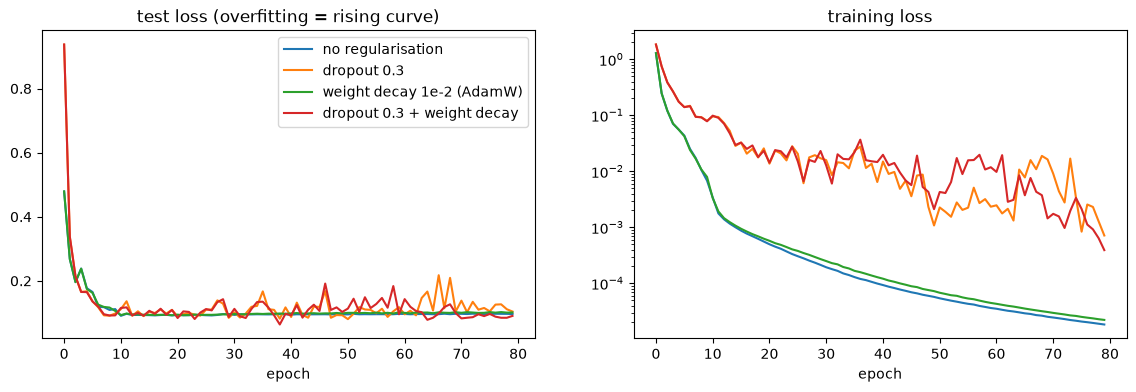

,final test acc,min test loss,final test loss
config,,,
no regularisation,0.9759,0.0909,0.0966
dropout 0.3,0.9722,0.0805,0.1043
weight decay 1e-2 (AdamW),0.9741,0.0928,0.1013
dropout 0.3 + weight decay,0.9796,0.0638,0.0907


In [5]:
configs = {"no regularisation": dict(dropout=0.0, wd=0.0), "dropout 0.3": dict(dropout=0.3, wd=0.0),
           "weight decay 1e-2 (AdamW)": dict(dropout=0.0, wd=1e-2), "dropout 0.3 + weight decay": dict(dropout=0.3, wd=1e-2)}
fig, axes = plt.subplots(1, 2, figsize=(14, 4)); rows = []
for name, cfg in configs.items():
    torch.manual_seed(0); m = deep_mlp(3, width=512, init="he", dropout=cfg["dropout"])
    h = train(m, epochs=80, opt=torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=cfg["wd"]))
    axes[0].plot(h.test_loss, label=name); axes[1].plot(h.train_loss, label=name)
    rows.append({"config": name, "final test acc": h.test_acc.iloc[-1], "min test loss": h.test_loss.min(), "final test loss": h.test_loss.iloc[-1]})
axes[0].set(title="test loss (overfitting = rising curve)", xlabel="epoch"); axes[1].set(title="training loss", yscale="log", xlabel="epoch"); axes[0].legend(); plt.show()
pd.DataFrame(rows).set_index("config").round(4)

## **4. Learning-Rate Schedules**

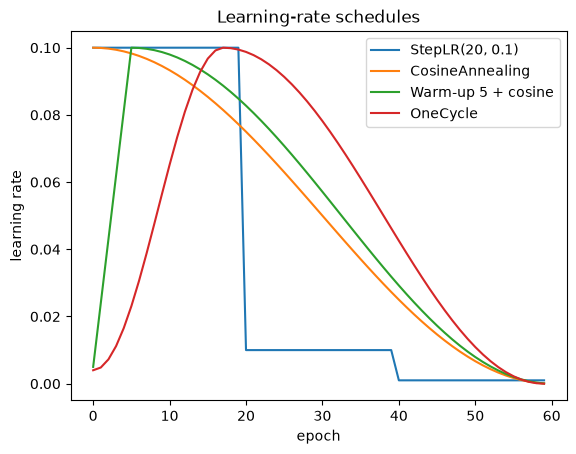

In [6]:
def lr_trace(make_sched, epochs=60, steps_per_epoch=1):
    p = nn.Parameter(torch.zeros(1)); o = torch.optim.SGD([p], lr=0.1); s = make_sched(o); lrs = []
    for _ in range(epochs * steps_per_epoch):
        lrs.append(o.param_groups[0]["lr"]); o.step(); s.step()
    return lrs
scheds = {"StepLR(20, 0.1)": lambda o: torch.optim.lr_scheduler.StepLR(o, 20, 0.1),
          "CosineAnnealing": lambda o: torch.optim.lr_scheduler.CosineAnnealingLR(o, 60),
          "Warm-up 5 + cosine": lambda o: torch.optim.lr_scheduler.SequentialLR(o, [torch.optim.lr_scheduler.LinearLR(o, 0.05, 1.0, 5), torch.optim.lr_scheduler.CosineAnnealingLR(o, 55)], [5]),
          "OneCycle": lambda o: torch.optim.lr_scheduler.OneCycleLR(o, max_lr=0.1, total_steps=60)}
for k, f in scheds.items(): plt.plot(lr_trace(f), label=k)
plt.legend(); plt.xlabel("epoch"); plt.ylabel("learning rate"); plt.title("Learning-rate schedules"); plt.show()

In [7]:
rows = []
for name in ["constant", "cosine", "one-cycle"]:
    torch.manual_seed(0); m = deep_mlp(4, width=256, init="he", bn=True)
    o = torch.optim.SGD(m.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    s = {"constant": None, "cosine": torch.optim.lr_scheduler.CosineAnnealingLR(o, 40),
         "one-cycle": torch.optim.lr_scheduler.OneCycleLR(o, max_lr=0.2, total_steps=40 * len(dl_tr))}[name]
    h = train(m, epochs=40, opt=o, sched=s); rows.append({"schedule": name, "final test acc": h.test_acc.iloc[-1], "final test loss": h.test_loss.iloc[-1]})
pd.DataFrame(rows).set_index("schedule").round(4)

,final test acc,final test loss
schedule,,
constant,0.9778,0.0681
cosine,0.9759,0.0755
one-cycle,0.9796,0.0781


### The learning-rate range test (Smith, 2017)
Increase the learning rate exponentially during one short run and plot the loss. Pick a learning rate roughly 10x below where the loss starts to explode.

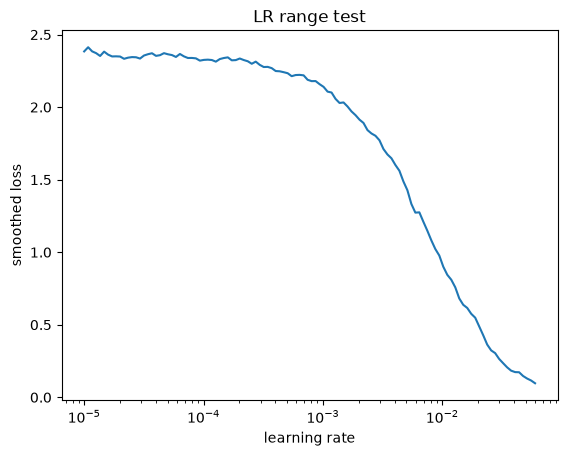

In [8]:
torch.manual_seed(0); m = deep_mlp(4, width=256, init="he", bn=True); o = torch.optim.SGD(m.parameters(), lr=1e-5, momentum=0.9)
lrs, losses, lr = [], [], 1e-5
for i, (xb_, yb_) in enumerate(list(dl_tr) * 6):
    for g in o.param_groups: g["lr"] = lr
    o.zero_grad(); l_ = nn.CrossEntropyLoss()(m(xb_), yb_); l_.backward(); o.step()
    lrs.append(lr); losses.append(l_.item()); lr *= 1.08
    if l_.item() > 4 * min(losses) or lr > 10: break
plt.semilogx(lrs, pd.Series(losses).ewm(alpha=0.2).mean()); plt.xlabel("learning rate"); plt.ylabel("smoothed loss"); plt.title("LR range test"); plt.show()

## **5. Gradient Clipping**
Rescale the gradient if its norm exceeds a threshold: `nn.utils.clip_grad_norm_(model.parameters(), max_norm)`. Essential for RNNs (Day 66) and useful whenever loss spikes appear.

# **Part 2: Going Deeper - A Debugging Checklist**

When a network does not learn:
1. **Overfit one small batch first.** A correct model + loss + optimiser must reach ~0 loss on 32 samples. If not, there is a bug.
2. Check the **initial loss**: for K balanced classes it should be about $\ln K$.
3. Check inputs (normalised? labels aligned? correct dtype `long` for CrossEntropy?).
4. Monitor activation and gradient statistics per layer (dead ReLUs, exploding norms).
5. Try a smaller learning rate; then a bigger model; then regularise.

In [9]:
torch.manual_seed(0); m = deep_mlp(4, width=128, init="he")
xb_, yb_ = next(iter(dl_tr))
print(f"initial loss {nn.CrossEntropyLoss()(m(xb_), yb_).item():.3f} | ln(10) = {np.log(10):.3f}")
o = torch.optim.Adam(m.parameters(), 1e-3)
for step in range(200):
    o.zero_grad(); l_ = nn.CrossEntropyLoss()(m(xb_), yb_); l_.backward(); o.step()
print(f"loss after overfitting one batch for 200 steps: {l_.item():.5f}  -> the pipeline can learn")

dead = []
h_ = xb_
for layer in m:
    h_ = layer(h_)
    if isinstance(layer, nn.ReLU): dead.append((h_ == 0).all(0).float().mean().item())
print("fraction of dead ReLU units per layer:", np.round(dead, 3))

initial loss 2.298 | ln(10) = 2.303


loss after overfitting one batch for 200 steps: 0.00011  -> the pipeline can learn
fraction of dead ReLU units per layer: [0.141 0.156 0.273 0.195]


### Residual connections (preview of Day 63)
Instead of learning $h_{l+1} = F(h_l)$, learn $h_{l+1} = h_l + F(h_l)$. The identity path lets gradients flow directly through very deep networks (He et al., 2016).

In [10]:
class ResBlock(nn.Module):
    def __init__(self, w):
        super().__init__(); self.f = nn.Sequential(nn.Linear(w, w), nn.BatchNorm1d(w), nn.ReLU(), nn.Linear(w, w), nn.BatchNorm1d(w))
    def forward(self, x):
        return torch.relu(x + self.f(x))
deep_res = nn.Sequential(nn.Linear(64, 128), nn.ReLU(), *[ResBlock(128) for _ in range(15)], nn.Linear(128, 10))
deep_plain = deep_mlp(31, width=128)
for name, m in [("31 plain layers (default init)", deep_plain), ("15 residual blocks (31 layers)", deep_res)]:
    torch.manual_seed(0); h = train(m, epochs=30); print(f"{name:<32} final test accuracy {h.test_acc.iloc[-1]:.3f}")

31 plain layers (default init)   final test accuracy 0.100


15 residual blocks (31 layers)   final test accuracy 0.922


## **Practice Problems**
1. Replace ReLU by tanh in `deep_mlp(20)` and compare Xavier vs He initialisation by gradient norms.
2. Train the 3-layer, 512-wide network with dropout 0.1, 0.3, 0.5 and 0.7. Plot final test accuracy vs dropout.
3. Use `torch.optim.lr_scheduler.ReduceLROnPlateau` on the test loss (in real work: validation loss) and print when the LR changes.
4. *(Advanced)* Implement BatchNorm1d ourselves as an `nn.Module` (with running statistics and train/eval behaviour) and check it matches `nn.BatchNorm1d`.

xavier grad norms first/last layer: 0.0774 0.2069
he grad norms first/last layer: 0.4693 0.7224


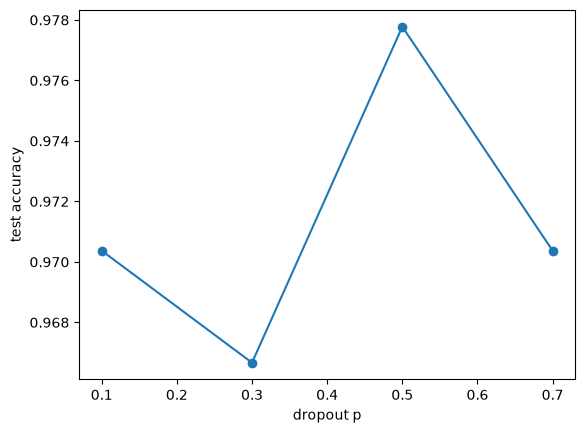

epoch 13: LR reduced to 9.00e-04
epoch 17: LR reduced to 2.70e-04


epoch 21: LR reduced to 8.10e-05
epoch 25: LR reduced to 2.43e-05


epoch 29: LR reduced to 7.29e-06
train mode equal: True
eval mode equal : True


In [11]:
# Solution 1
for init in ["xavier", "he"]:
    m = deep_mlp(20, act=nn.Tanh, init=init); nn.CrossEntropyLoss()(m(xb), torch.tensor(y_tr[:256])).backward()
    print(init, "grad norms first/last layer:", round(m[0].weight.grad.norm().item(), 4), round(m[-1].weight.grad.norm().item(), 4))
# Solution 2
accs = {}
for p in [0.1, 0.3, 0.5, 0.7]:
    torch.manual_seed(0); m = deep_mlp(3, width=512, init="he", dropout=p)
    accs[p] = train(m, epochs=60, opt=torch.optim.AdamW(m.parameters(), 1e-3)).test_acc.iloc[-1]
plt.plot(list(accs), list(accs.values()), "o-"); plt.xlabel("dropout p"); plt.ylabel("test accuracy"); plt.show()
# Solution 3
torch.manual_seed(0); m = deep_mlp(4, width=256, init="he"); o = torch.optim.Adam(m.parameters(), 3e-3)
plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(o, factor=0.3, patience=3)
for ep in range(30):
    m.train()
    for xb_, yb_ in dl_tr:
        o.zero_grad(); nn.CrossEntropyLoss()(m(xb_), yb_).backward(); o.step()
    m.eval()
    with torch.no_grad(): vl = nn.CrossEntropyLoss()(m(dl_te.dataset.tensors[0]), dl_te.dataset.tensors[1]).item()
    before = o.param_groups[0]["lr"]; plateau.step(vl)
    if o.param_groups[0]["lr"] != before: print(f"epoch {ep}: LR reduced to {o.param_groups[0]['lr']:.2e}")
# Solution 4
class MyBN(nn.Module):
    def __init__(self, n, eps=1e-5, momentum=0.1):
        super().__init__(); self.gamma = nn.Parameter(torch.ones(n)); self.beta = nn.Parameter(torch.zeros(n)); self.eps, self.mom = eps, momentum
        self.register_buffer("rm", torch.zeros(n)); self.register_buffer("rv", torch.ones(n))
    def forward(self, x):
        if self.training:
            mu, var = x.mean(0), x.var(0, unbiased=False)
            with torch.no_grad():
                self.rm.mul_(1 - self.mom).add_(self.mom * mu); self.rv.mul_(1 - self.mom).add_(self.mom * x.var(0, unbiased=True))
        else:
            mu, var = self.rm, self.rv
        return self.gamma * (x - mu) / torch.sqrt(var + self.eps) + self.beta
mine, ref = MyBN(3), nn.BatchNorm1d(3)
print("train mode equal:", torch.allclose(mine(data), ref(data), atol=1e-5)); mine.eval(); ref.eval()
print("eval mode equal :", torch.allclose(mine(data), ref(data), atol=1e-5))

## **Key References**
- Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks. *AISTATS 2010*.
- He, K., Zhang, X., Ren, S., & Sun, J. (2015). Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification. *ICCV 2015*.
- Ioffe, S., & Szegedy, C. (2015). Batch normalization: Accelerating deep network training by reducing internal covariate shift. *ICML 2015*.
- Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *JMLR*, 15, 1929-1958.
- Loshchilov, I., & Hutter, F. (2017). SGDR: Stochastic gradient descent with warm restarts. *ICLR 2017*.
- Smith, L. N. (2017). Cyclical learning rates for training neural networks. *WACV 2017*.
- Karpathy, A. (2019). A recipe for training neural networks. karpathy.github.io/2019/04/25/recipe.